In [1]:
#imports cell
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
links_df = pd.read_csv("../data/links.csv")
movies_df = pd.read_csv("../data/movies.csv")
ratings_df = pd.read_csv("../data/ratings.csv")
tags_df = pd.read_csv("../data/tags.csv")

In [3]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
tags_df

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


# Data exploration

# Movies dataset

In [7]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [8]:
# Descriptive analysis of the dataset (exclusive of id column)
movies_df.iloc[ :, 1:].describe()

,title,genres
count,9742,9742
unique,9737,951
top,War of the Worlds (2005),Drama
freq,2,1053


* We can see that drama is the genre combination with most entries.
* We can see the modal title is Emma(1996) with a frequency of 2 meaning it's possibly a duplicate.
* From the dataframes metadata we have 9742 entries but we only see 9737 unique values in the title column meaning 5 rows might be duplicates.

In [9]:
movies_df[movies_df["title"] == "Emma (1996)"]

,movieId,title,genres
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance


In [10]:
# Let's look at the columns with duplicates
movies_df[movies_df["title"].duplicated(keep=False)].sort_values("title")

,movieId,title,genres
4169,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance
5854,32600,Eros (2004),Drama
9135,147002,Eros (2004),Drama|Romance
2141,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller
5931,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
6932,64997,War of the Worlds (2005),Action|Sci-Fi


We can see a pattern in the duplicates here. The duplicates share a name with the originals and also the release year. From experience this is highly unlikely. We see while genres differ the duplicates contain atleast one genre from the original so we have to drop them.

We have specific rows we need to drop and also, the duplicates might have references in the other datasets which we will have to drop. For this table specifically we will put the duplicate(rows with the fewer genres) id's in an array and drop them one by one while in the reference tables we can use a join to ensure only entities with entries in both tables are present. We can even repeat the step given for the movies dataset.

In [11]:
movies_to_be_dropped_ids = [6003, 26958, 32600,	168358, 64997]

In [12]:
movies_df_no_dups = movies_df
for i in movies_to_be_dropped_ids:
    movies_df_no_dups = movies_df_no_dups[movies_df_no_dups["movieId"] != i]

movies_df = movies_df_no_dups
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9737 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9737 non-null   int64 
 1   title    9737 non-null   object
 2   genres   9737 non-null   object
dtypes: int64(1), object(2)
memory usage: 304.3+ KB


In [13]:
# Let's look at the columns with duplicates again
movies_df[movies_df["title"].duplicated(keep=False)].sort_values("title")

,movieId,title,genres


Great, we have dealt with the duplicates. However, the "genres" column has a problem. It is in the format of "Action|Adventure|Sci-Fi|", which is a pipe ('|') separated string meant to convey many genres in one string object. This is usable but it is more usable for analysis and modelling if it is separated out.<br>
Doing this for both tasks is not going to be easy. But one easy way we can do this is create another genre and movie table that has a movieId and individual genre combo as the rows.

In [14]:
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [15]:
def separate_genres(row):
    genre_movies[row["movieId"]] = row["genres"].split("|")

genre_movies = {}
movies_df.copy().apply( separate_genres, axis=1)

genre_movies

{1: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy'],
 2: ['Adventure', 'Children', 'Fantasy'],
 3: ['Comedy', 'Romance'],
 4: ['Comedy', 'Drama', 'Romance'],
 5: ['Comedy'],
 6: ['Action', 'Crime', 'Thriller'],
 7: ['Comedy', 'Romance'],
 8: ['Adventure', 'Children'],
 9: ['Action'],
 10: ['Action', 'Adventure', 'Thriller'],
 11: ['Comedy', 'Drama', 'Romance'],
 12: ['Comedy', 'Horror'],
 13: ['Adventure', 'Animation', 'Children'],
 14: ['Drama'],
 15: ['Action', 'Adventure', 'Romance'],
 16: ['Crime', 'Drama'],
 17: ['Drama', 'Romance'],
 18: ['Comedy'],
 19: ['Comedy'],
 20: ['Action', 'Comedy', 'Crime', 'Drama', 'Thriller'],
 21: ['Comedy', 'Crime', 'Thriller'],
 22: ['Crime', 'Drama', 'Horror', 'Mystery', 'Thriller'],
 23: ['Action', 'Crime', 'Thriller'],
 24: ['Drama', 'Sci-Fi'],
 25: ['Drama', 'Romance'],
 26: ['Drama'],
 27: ['Children', 'Drama'],
 28: ['Drama', 'Romance'],
 29: ['Adventure', 'Drama', 'Fantasy', 'Mystery', 'Sci-Fi'],
 30: ['Crime', 'Drama'],
 31: ['D

In [16]:
# A function to visually inspect if what we've done is correct
def check_genre_movies(movieId):
    print(movies_df[movies_df["movieId"] == movieId]["genres"])
    print(genre_movies[movieId])

# A test function that tests all entries in movie_df and genre_movies match
def test_genre_movies():
    for i, row in movies_df.iterrows():
        val = genre_movies.get(row["movieId"]) #Get the genre_movies entry for this row
        exp = row["genres"].split("|") #Perform the spliting operation for the corresponding genres
        #exp.append("huh")  #uncomment this line to test if the assert works
        assert val == exp, f"Wrong paring for df -{exp}   dict{val}" #An assert to check if they are equal
    return True # Returns true to indicate the genre_movies dictionary has correct values from top to bottom

In [17]:
# 
check_genre_movies(100)

88    Drama|Thriller
Name: genres, dtype: object
['Drama', 'Thriller']


In [18]:
# When 
test_genre_movies()

True

In [19]:
#create the new dataframe
genre_movie_df = pd.DataFrame(columns=["movieId", "genre"])
genre_movie_df


,movieId,genre


In [20]:
for i,genres in genre_movies.items():
    for g in genres:
        genre_movie_df = pd.concat([genre_movie_df, pd.DataFrame([{"movieId": i,"genre":g}])], ignore_index=True)

genre_movie_df


,movieId,genre
0,1,Adventure
1,1,Animation
2,1,Children
3,1,Comedy
4,1,Fantasy
...,...,...
22069,193583,Fantasy
22070,193585,Drama
22071,193587,Action
22072,193587,Animation


In [21]:
#Saved the dataframe to its own csv. We save in the generated folder to separate it from the main  project 
# data files. You can save it anywhere you like, this is our preference.

# Make sure you have created the generated folder inside the data folder if you use our save path
genre_movie_df.to_csv("../data/generated/genre_movie.csv", index=False) 

* We now have a separate dataset containing movieId-genre pairing. This makes it so that one movie has only one genre so we can do more complex queries on the data.
* Let's now do some simple analysis on the genres

In [22]:
genre_movie_df["genre"].value_counts()

Drama                 4359
Comedy                3755
Thriller              1892
Action                1827
Romance               1595
Adventure             1263
Crime                 1198
Sci-Fi                 978
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: genre, dtype: int64

In [23]:
# Deal with the no genres listed

* Above we can see the count of all the genres.
* Drama is the most common genre while film-noir is the least.
* We have 34 movies with no genres
<br>
Below lets look at the genre combinations

In [24]:
movies_df["genres"].value_counts()

Drama                                        1052
Comedy                                        946
Comedy|Drama                                  435
Comedy|Romance                                363
Drama|Romance                                 349
                                             ... 
Adventure|Children|Comedy|Fantasy|Mystery       1
Action|Fantasy|War|IMAX                         1
Comedy|Romance|Western                          1
Adventure|Drama|Sci-Fi|Thriller                 1
Comedy|Fantasy|Mystery|Sci-Fi                   1
Name: genres, Length: 951, dtype: int64

While we have 951 different genres, drama and comedy still outrank all the combinations while the combination of the two also outranks the rest!

# ratings df

In [25]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [26]:
ratings_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


* No null values in this dataset
* Rating column is given a range from 0-5. However, our minimum rating is 0.5

In [27]:
# No duplicate rows in the dataset
ratings_df[ratings_df.duplicated()]

,userId,movieId,rating,timestamp


In [28]:
# Let's look at the tags_df
tags_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB


No null values are present in the data.

In [29]:
# Dropping the timestamp columns in ratings and tags since we don't need them
ratings_df = ratings_df.drop(columns=["timestamp"])
tags_df = tags_df.drop(columns=["timestamp"])


In [30]:
tags_df.head()

,userId,movieId,tag
0,2,60756,funny
1,2,60756,Highly quotable
2,2,60756,will ferrell
3,2,89774,Boxing story
4,2,89774,MMA


links and tag tables are likely not usefull to us so we won't really bother with them.

# Further Analysis and Visualization

We already looked at the genre table. Now lets plot our results

In [31]:
genre_counts = genre_movie_df["genre"].value_counts()
genre_counts

Drama                 4359
Comedy                3755
Thriller              1892
Action                1827
Romance               1595
Adventure             1263
Crime                 1198
Sci-Fi                 978
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: genre, dtype: int64

In [32]:
type(genre_counts)

pandas.core.series.Series

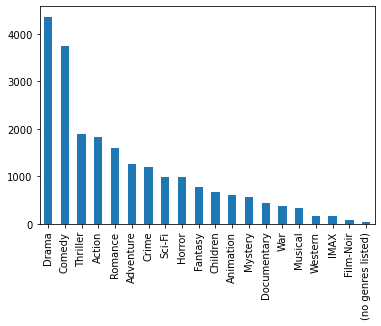

In [33]:
genre_counts.plot(kind="bar")
plt.show()

Below we explore the average rating of each movie

In [34]:
# Grouping the ratings by movie id so as to get the average rating for each movie
avg_ratings_per_movie = ratings_df.groupby("movieId")["rating"].mean()
avg_ratings_per_movie

movieId
1         3.920930
2         3.431818
3         3.259615
4         2.357143
5         3.071429
            ...   
193581    4.000000
193583    3.500000
193585    3.500000
193587    3.500000
193609    4.000000
Name: rating, Length: 9724, dtype: float64

In [35]:
type(avg_ratings_per_movie)

pandas.core.series.Series

<AxesSubplot:xlabel='rating', ylabel='Count'>

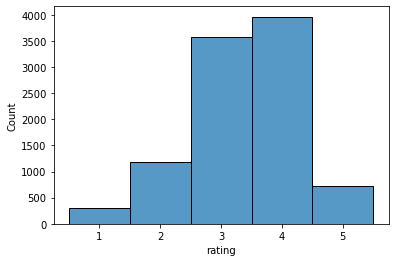

In [36]:
sns.histplot(x=avg_ratings_per_movie, bins=np.arange(0.5, 6.5, 1))

Most movies are rated at the range of 2.5-4.5 and we can see it is a normal distribution.

In [37]:
# Below we do a left join of movies_df and avg_ratings_per_movie using the movieId table that is mutual to both. This ensures all rated movies get their rating
movie_rating = movies_df.join(avg_ratings_per_movie, on="movieId").sort_values("rating", ascending=False) 
movie_rating

,movieId,title,genres,rating
7656,88448,Paper Birds (Pájaros de papel) (2010),Comedy|Drama,5.0
8107,100556,"Act of Killing, The (2012)",Documentary,5.0
9083,143031,Jump In! (2007),Comedy|Drama|Romance,5.0
9094,143511,Human (2015),Documentary,5.0
9096,143559,L.A. Slasher (2015),Comedy|Crime|Fantasy,5.0
...,...,...,...,...
5749,30892,In the Realms of the Unreal (2004),Animation|Documentary,NaN
5824,32160,Twentieth Century (1934),Comedy,NaN
5837,32371,Call Northside 777 (1948),Crime|Drama|Film-Noir,NaN
5957,34482,"Browning Version, The (1951)",Drama,NaN


Let's look at the top rated movies

In [38]:
movie_rating.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9737 entries, 7656 to 7565
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9737 non-null   int64  
 1   title    9737 non-null   object 
 2   genres   9737 non-null   object 
 3   rating   9719 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 380.4+ KB


In [39]:
movie_rating.describe()

,movieId,rating
count,9737.000000,9719.000000
mean,42191.324741,3.262470
std,52156.096198,0.870046
min,1.000000,0.500000
25%,3247.000000,2.800000
50%,7297.000000,3.416667
75%,76251.000000,3.912872
max,193609.000000,5.000000


In [40]:
# Let's deal with the rating by imputing with the mean
movie_rating["rating"] = movie_rating["rating"].fillna(movie_rating["rating"].mean())
movie_rating[movie_rating["rating"].isna()]

,movieId,title,genres,rating


In [41]:
movie_rating[movie_rating.duplicated()] # No duplicates available

,movieId,title,genres,rating


In [42]:
movie_rating.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9737 entries, 7656 to 7565
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9737 non-null   int64  
 1   title    9737 non-null   object 
 2   genres   9737 non-null   object 
 3   rating   9737 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 380.4+ KB


The dataset is now clean and ready to be worked omn

In [43]:
# Lets plot a histogram of the movies and and the ratings 
perfect_movies = movie_rating[movie_rating["rating"] >= 5 ]
perfect_movies

,movieId,title,genres,rating
7656,88448,Paper Birds (Pájaros de papel) (2010),Comedy|Drama,5.0
8107,100556,"Act of Killing, The (2012)",Documentary,5.0
9083,143031,Jump In! (2007),Comedy|Drama|Romance,5.0
9094,143511,Human (2015),Documentary,5.0
9096,143559,L.A. Slasher (2015),Comedy|Crime|Fantasy,5.0
...,...,...,...,...
5493,26350,"Passenger, The (Professione: reporter) (1975)",Drama,5.0
3672,5059,Little Dieter Needs to Fly (1997),Documentary,5.0
5345,8911,Raise Your Voice (2004),Romance,5.0
4109,5889,"Cruel Romance, A (Zhestokij Romans) (1984)",Drama|Romance,5.0


# Modelling

In this section, we will first create a Memory-based base model

In [ ]:
#modelling imports
from suprise import knns


ModuleNotFoundError: No module named 'suprise'